In [1]:
import json
import os
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
with open("Cluster_dictionary_with_rna_type.txt", "r", encoding="utf-8") as f:
    data = json.load(f)

['Ribosome', 'RNA', 'other Proteins', 'RNA-RNA/DNA'] [389, 191, 115, 8]


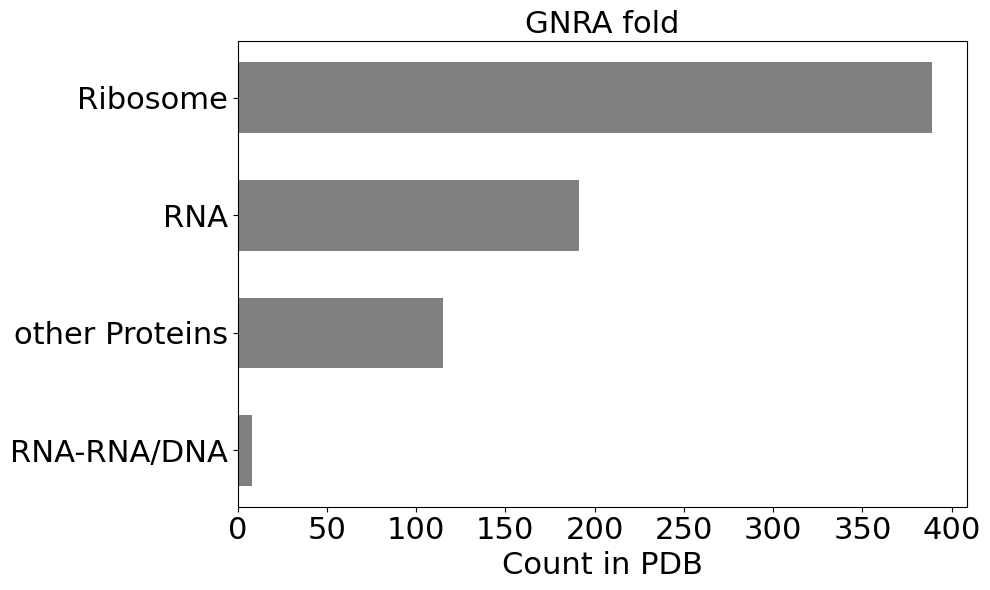

['Ribosome', 'RNA', 'other Proteins', 'RNA-RNA/DNA'] [277, 63, 29, 0]


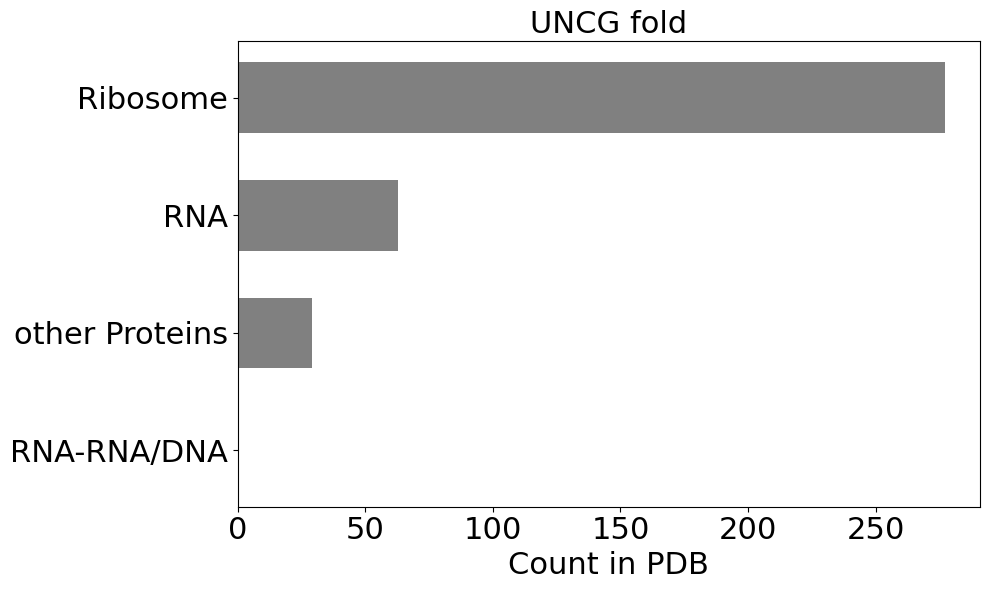

['Ribosome', 'RNA', 'other Proteins', 'RNA-RNA/DNA'] [265, 9, 3, 0]


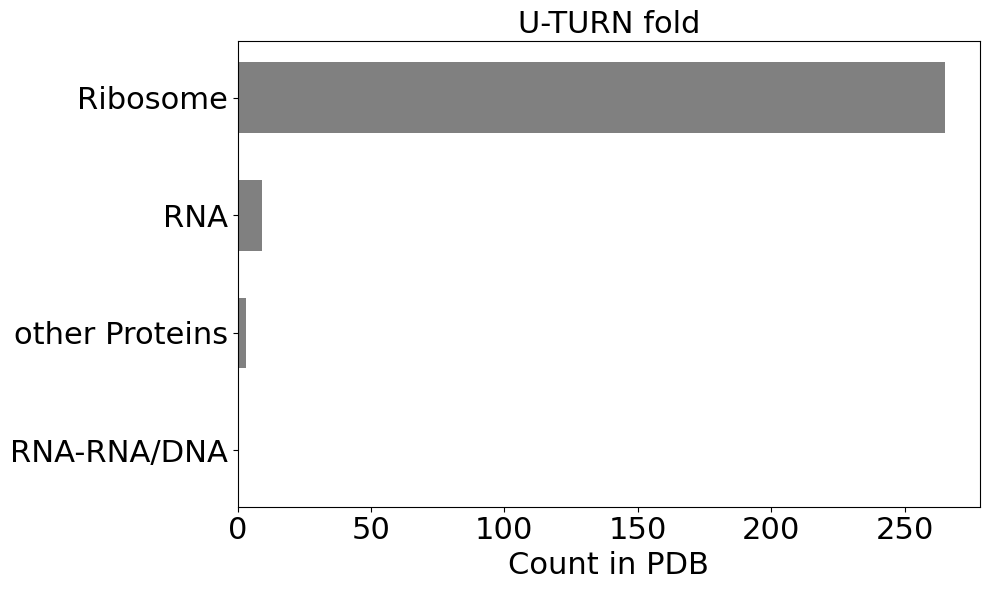

['Ribosome', 'RNA', 'other Proteins', 'RNA-RNA/DNA'] [191, 3, 4, 0]


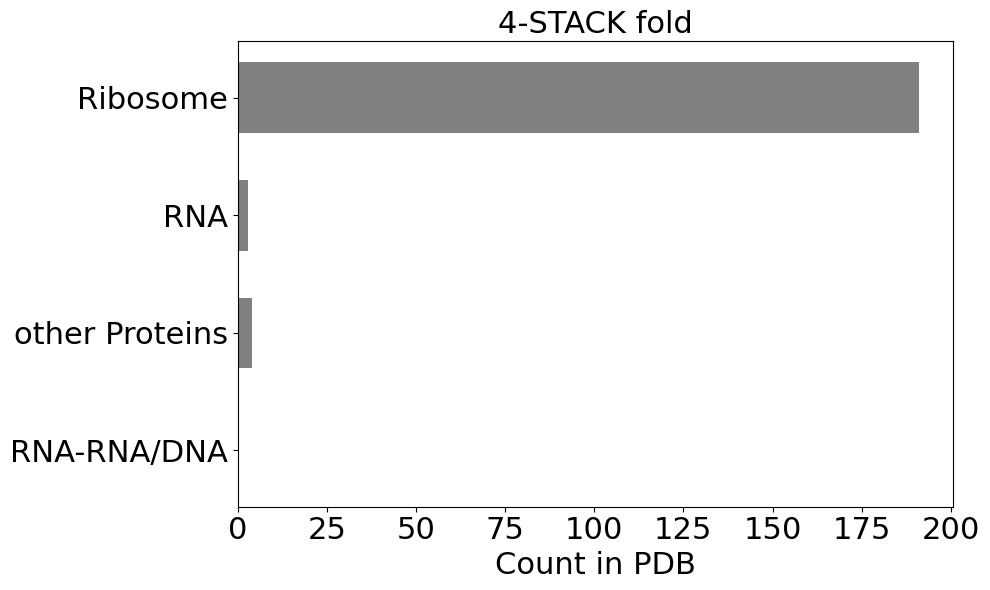

['Ribosome', 'RNA', 'other Proteins', 'RNA-RNA/DNA'] [67, 0, 18, 0]


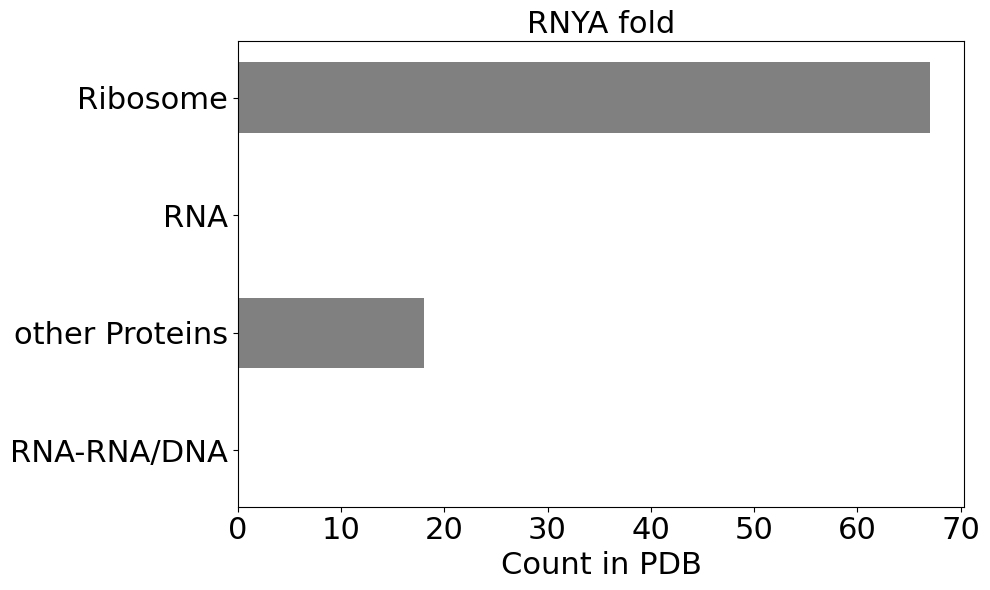

['Ribosome', 'RNA', 'other Proteins', 'RNA-RNA/DNA'] [2, 3, 3, 0]


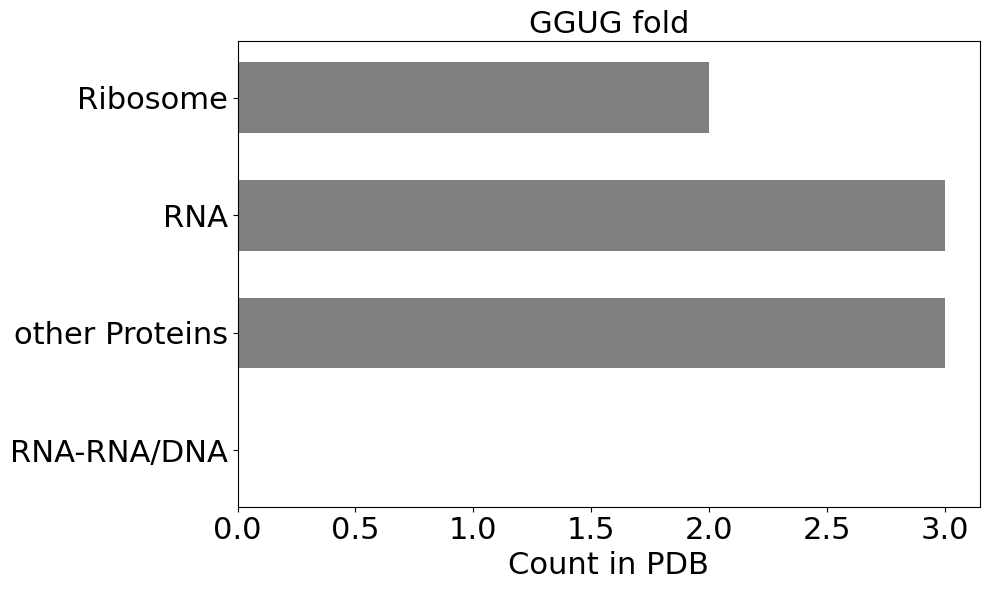

['Ribosome', 'RNA', 'other Proteins', 'RNA-RNA/DNA'] [0, 2, 0, 0]


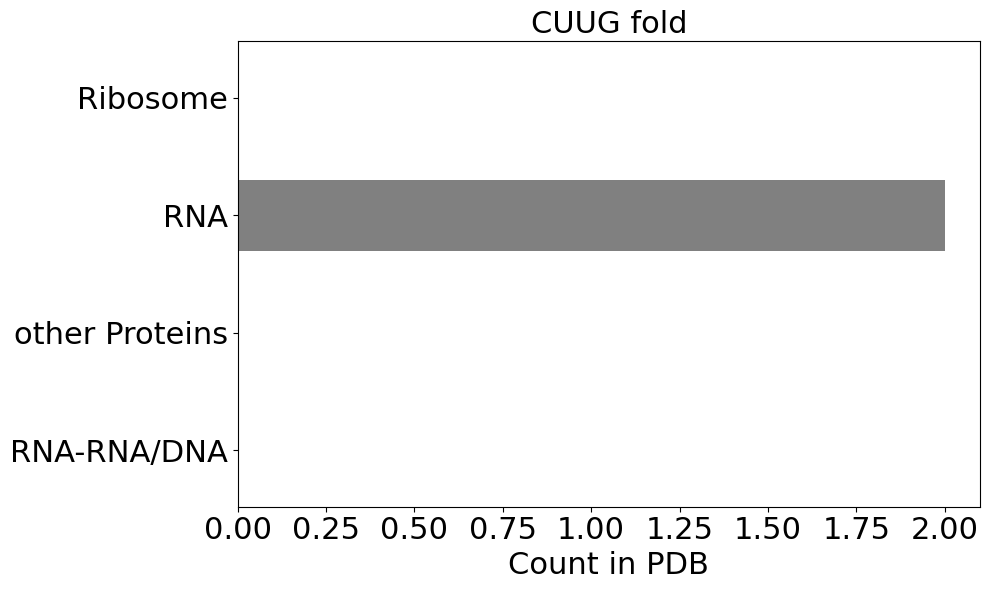

['Ribosome', 'RNA', 'other Proteins', 'RNA-RNA/DNA'] [0, 2, 0, 0]


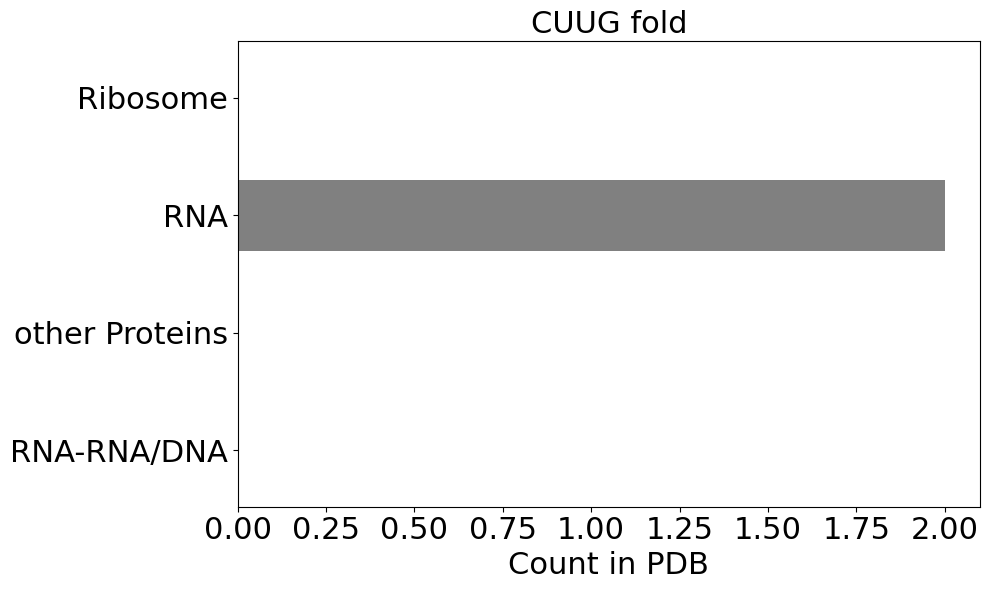

['Ribosome', 'RNA', 'other Proteins', 'RNA-RNA/DNA'] [0, 1, 2, 0]


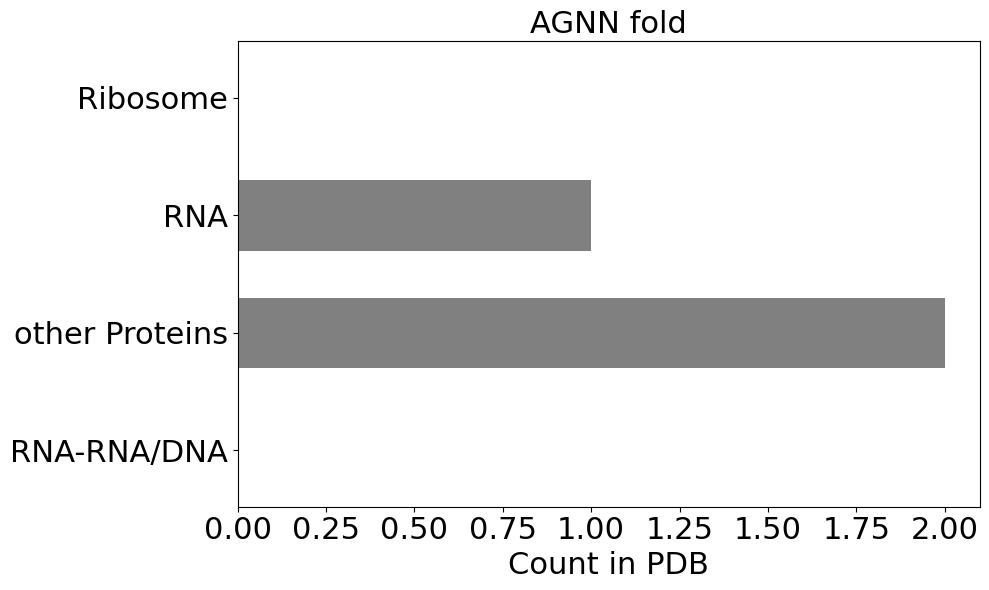

saved in folder: plots_PDB_origins


In [13]:
output_folder = "plots_PDB_origins"
os.makedirs(output_folder, exist_ok=True)

loop_labels = {"01": "GNRA",
               "02": "UNCG",
               "04": "U-TURN",
               "11": "4-STACK",
               "21": "RNYA",
               "30": "GGUG",
               "35": "CUUG",
               "38": "CUUG",
               "39": "AGNN",
               }

# === bar plot for every ID ===
for ID, categories in data.items():
    # count catergorys
    #dd = {"Ribosome": 0}
    category_counts = defaultdict(int)
    for category, count in categories.items():
        normalized = category.upper()
        category_counts[normalized] += count

    # sort after population
    sorted_items = sorted(category_counts.items(), key=lambda x: x[1], reverse=True)
    #labels, values = zip(*sorted_items)
    categories_reduced = {"Ribosome": 0, "RNA": 0, "other Proteins": 0, "RNA-RNA/DNA": 0}
    ribo   = ['RIBOSOME','RIBOSOME/ANTIBIOTIC','RIBOSOME/INHIBITOR','RIBOSOME/RIBOSOME INHIBITOR', 'RIBOSOMAL PROTEIN/RNA']
    rna    = ['RNA','RIBONUCLEIC ACID','RNA RIBOZYME','RIBOZYME']
    rna_rna = ('DNA, RNA','RNA/RNA','RNA/RNA BINDING')
    for item in sorted_items:
        if item[0] in ribo:
            categories_reduced["Ribosome"] += item[1]
        elif item[0] in rna:
            categories_reduced["RNA"] += item[1]
        elif item[0] in rna_rna:
            categories_reduced["RNA-RNA/DNA"] += item[1]
        else:
            categories_reduced["other Proteins"] += item[1]

    labels=list(categories_reduced.keys())
    values=list(categories_reduced.values())
    print(labels, values)
          

    ## Optional: only show top n
    #top_n = 40
    #top_items = sorted_items[:top_n]
    #labels, values = zip(*top_items)
    #print(labels, values)

    # Diagramm erstellen
    plt.figure(figsize=(10, 6))
    plt.barh(labels, values, height=0.6, color='grey')
    plt.xlabel("Count in PDB", fontdict={"size":22})
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    plt.title(f"{loop_labels[ID]} fold", fontdict={"size":22})
    plt.gca().invert_yaxis()
    plt.tight_layout()

    # Diagramm speichern
    plt.savefig(f"{output_folder}/bar_plot_{ID}_reduced.png")
    #plt.savefig(f"{output_folder}/bar_plot_{ID}_reduced.pdf")
    plt.show()
    plt.close()

print(f"saved in folder: {output_folder}")